<a href="https://colab.research.google.com/github/JuTluszcz/GEOPROCESSAMENTO/blob/master/ArvoreXGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive

try:
    drive.mount('/content/drive')
    print("✅ Google Drive montado com sucesso!")
except Exception as e:
    print(f"🚨 Erro ao montar o Google Drive: {e}")

Mounted at /content/drive
✅ Google Drive montado com sucesso!


In [ ]:
!ls "/content/drive/MyDrive/MESTRADO/Embrapa/parciais"

'ags_anual_2001_2025_parana (1).csv'
 base_mestre_soja_deral_marcha_ibge.csv
 base_municipios_top85_area.csv
'base_pronta_com_ags_corrigida (1).csv'
 MarchacomAgs.csv


In [3]:
# Carregar o dataset principal
caminho_csv = "/content/drive/MyDrive/MESTRADO/Embrapa/parciais/MarchacomAgs.csv"
df = pd.read_csv(caminho_csv)

# Criar a coluna alvo 'Produtividade_kg_ha'
df['Produtividade_kg_ha'] = (df['PRODUCAO (t)'] * 1000) / df['AREA TOTAL (ha)']

# Lidar com valores NaN ou infinitos na coluna alvo
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['Produtividade_kg_ha'], inplace=True)

# Criar a coluna 'ano_safra' a partir de 'SAFRA'
df['ano_safra'] = df['SAFRA'].str.split('/').str[1].astype(int) + 2000

In [4]:
print("Iniciando o cálculo de Detrending...")

TARGET_ORIGINAL = 'Produtividade_kg_ha'
TARGET_ANOMALIA = 'Produtividade_Anomalia'

lista_municipios = df['Município'].unique()
df_list = []

for municipio in lista_municipios:
    # Ordenar cronologicamente para regressão
    df_city = df[df['Município'] == municipio].sort_values('ano_safra').copy()

    if len(df_city) < 2:
        # Se não houver pontos suficientes para reta de tendência, a anomalia é zero
        df_city[TARGET_ANOMALIA] = 0
        df_list.append(df_city)
        continue

    X_trend = df_city[['ano_safra']]
    y_trend = df_city[TARGET_ORIGINAL]

    # Criar modelo de tendência
    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)
    produtividade_esperada = trend_model.predict(X_trend)

    # O novo alvo passa a ser a diferença (anomalia)
    df_city[TARGET_ANOMALIA] = df_city[TARGET_ORIGINAL] - produtividade_esperada
    df_list.append(df_city)

# Reconstruir o DataFrame agora sem a tendência histórica
df_detrended = pd.concat(df_list)
print(f"Coluna '{TARGET_ANOMALIA}' criada com sucesso!")

Iniciando o cálculo de Detrending...
Coluna 'Produtividade_Anomalia' criada com sucesso!


In [5]:
df_detrended.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4804 entries, 0 to 4784
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SAFRA                       4804 non-null   object 
 1   CULTURA                     4804 non-null   object 
 2   Município                   4804 non-null   object 
 3   geocodigo_ibge              4804 non-null   int64  
 4   REGIAO                      4804 non-null   object 
 5   NUCLEO REGIONAL             4804 non-null   object 
 6   AREA TOTAL (ha)             4804 non-null   float64
 7   PRODUCAO (t)                4804 non-null   float64
 8   prod_agregada_regional (t)  4804 non-null   float64
 9   Plantio_25%                 4804 non-null   object 
 10  Plantio_50%                 4804 non-null   object 
 11  Plantio_75%                 4804 non-null   object 
 12  Colheita_25%                4804 non-null   object 
 13  Colheita_50%                4804 non-n

In [6]:
# Identificar e converter colunas categóricas nativas para o XGBoost
categorical_cols = [
    'CULTURA', 'REGIAO', 'NUCLEO REGIONAL', 'Município',
    'Plantio_25%', 'Plantio_50%', 'Plantio_75%',
    'Colheita_25%', 'Colheita_50%', 'Colheita_75%',
    'Labelc', 'sowday'
]

for col in categorical_cols:
    if col in df_detrended.columns:
        df_detrended[col] = df_detrended[col].astype('category')

# Definir as features removendo alvos e identificadores textuais indesejados
cols_to_drop = [
    'Produtividade_kg_ha', 'ano_safra', 'SAFRA',
    'PRODUCAO (t)', 'AREA TOTAL (ha)', TARGET_ANOMALIA, 'Município', 'Labelc', 'sowday',
    'Colheita_25%', 'Colheita_50%', 'Colheita_75%', 'geocodigo_ibge', 'REGIAO',
    'NUCLEO REGIONAL', 'CULTURA', 'Plantio_25%', 'Plantio_50%', 'Plantio_75%',
    'prod_agregada_regional (t)', 'SowingY', 'SowingDay', 'Biomass_GRAINf'
]
FEATURES = [c for c in df_detrended.columns if c not in cols_to_drop]

X = df_detrended[FEATURES]
y = df_detrended[TARGET_ANOMALIA] # Prevendo a anomalia

# Divisão de 70% Treino, 10% Validação, 20% Teste (pode ser ajustado conforme a necessidade)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print("\nDivisão concluída:")
print(f"Formato X_train: {X_train.shape}")
print(f"Formato X_val: {X_val.shape}")
print(f"Formato X_test: {X_test.shape}")


Divisão concluída:
Formato X_train: (3362, 36)
Formato X_val: (481, 36)
Formato X_test: (961, 36)


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

print("Preparando dados para a Árvore de Decisão (Scikit-Learn não aceita categorias nativas)...")
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Convertendo categorias para códigos numéricos para a Árvore de Decisão
for col in categorical_cols:
    if col in X_train_tree.columns:
        X_train_tree[col] = X_train_tree[col].cat.codes
        X_test_tree[col] = X_test_tree[col].cat.codes

print("Treinando a Árvore de Decisão...")
# Usamos max_depth=6 para não ficar uma árvore gigantesca e sofrer overfitting muito rápido
modelo_arvore = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_arvore.fit(X_train_tree, y_train)

# Predições Árvore
y_pred_arvore_train = modelo_arvore.predict(X_train_tree)
y_pred_arvore_test = modelo_arvore.predict(X_test_tree)

Preparando dados para a Árvore de Decisão (Scikit-Learn não aceita categorias nativas)...
Treinando a Árvore de Decisão...


In [8]:
import xgboost as xgb

print("Iniciando o treinamento do XGBoost Otimizado...")
# Usando a mesma parametrização balanceada que criamos antes
modelo_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True
)


modelo_xgb.fit(X_train, y_train)

# Predições XGBoost
y_pred_xgb_train = modelo_xgb.predict(X_train)
y_pred_xgb_test = modelo_xgb.predict(X_test)
print("Treinamento do XGBoost concluído!")

Iniciando o treinamento do XGBoost Otimizado...
Treinamento do XGBoost concluído!


In [9]:
# Função auxiliar para não repetir código
def calcular_metricas(y_real, y_pred):
    return [
        round(mean_squared_error(y_real, y_pred), 4),
        round(r2_score(y_real, y_pred), 4),
        round(mean_absolute_error(y_real, y_pred), 4)
    ]

# Criando a tabela de comparação
df_comparacao = pd.DataFrame({
    'Método': ['Árvore de Decisão', 'XGBoost Otimizado'],
    'MSE TREINAMENTO': [calcular_metricas(y_train, y_pred_arvore_train)[0], calcular_metricas(y_train, y_pred_xgb_train)[0]],
    'R2 TREINAMENTO': [calcular_metricas(y_train, y_pred_arvore_train)[1], calcular_metricas(y_train, y_pred_xgb_train)[1]],
    'MAE TREINAMENTO': [calcular_metricas(y_train, y_pred_arvore_train)[2], calcular_metricas(y_train, y_pred_xgb_train)[2]],
    'MSE TESTE': [calcular_metricas(y_test, y_pred_arvore_test)[0], calcular_metricas(y_test, y_pred_xgb_test)[0]],
    'R2 TESTE': [calcular_metricas(y_test, y_pred_arvore_test)[1], calcular_metricas(y_test, y_pred_xgb_test)[1]],
    'MAE TESTE': [calcular_metricas(y_test, y_pred_arvore_test)[2], calcular_metricas(y_test, y_pred_xgb_test)[2]]
})

print("--- COMPARAÇÃO DE MODELOS: PREVISÃO DE ANOMALIA PRODUTIVA ---")
display(df_comparacao)

--- COMPARAÇÃO DE MODELOS: PREVISÃO DE ANOMALIA PRODUTIVA ---


,Método,MSE TREINAMENTO,R2 TREINAMENTO,MAE TREINAMENTO,MSE TESTE,R2 TESTE,MAE TESTE
0,Árvore de Decisão,127445.3239,0.6157,271.0256,165242.7593,0.5094,310.8620
1,XGBoost Otimizado,63340.2714,0.8090,191.1345,97778.0853,0.7097,238.0542


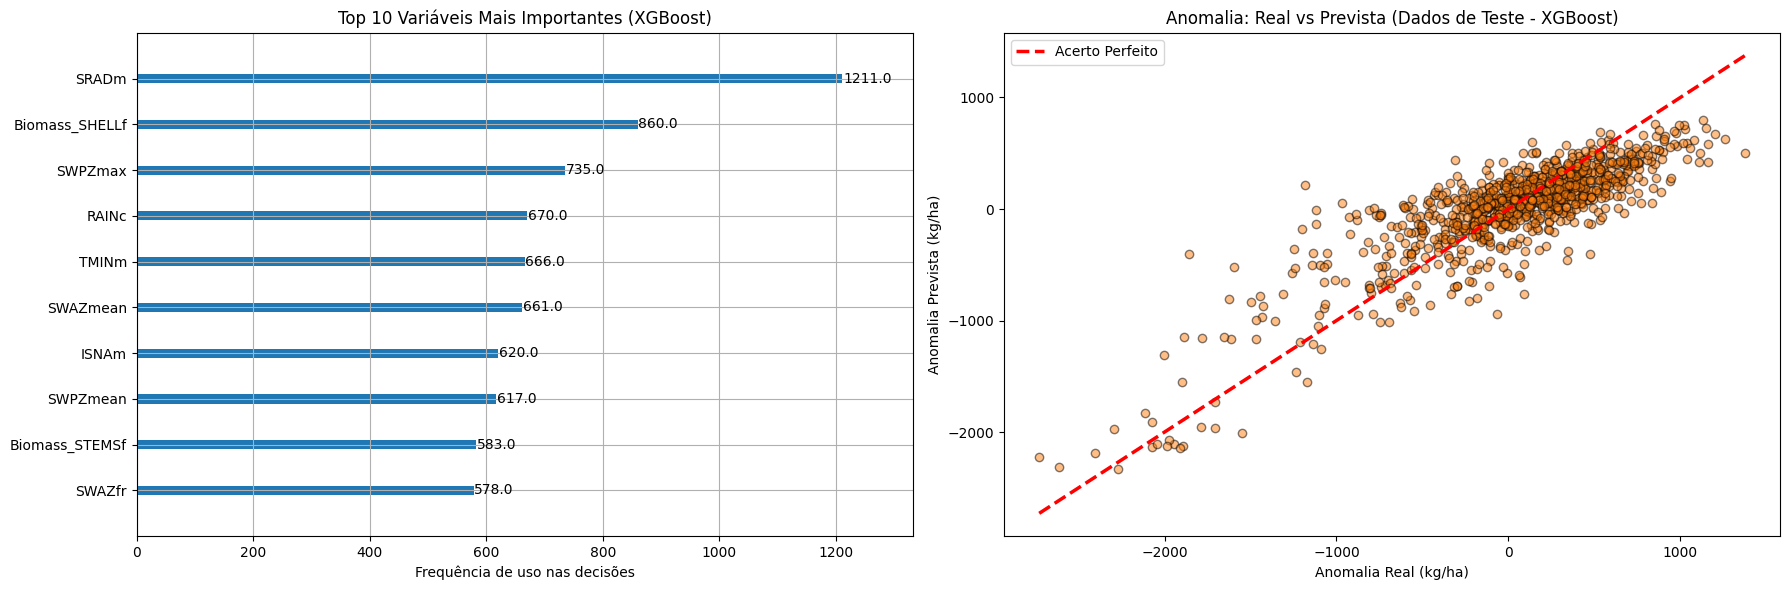

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Importância das 10 Variáveis mais importantes (XGBoost)
# Como tem 53 features, mostramos apenas as top 10 para o gráfico não ficar ilegível
xgb.plot_importance(modelo_xgb, ax=axes[0], importance_type='weight', max_num_features=10,
                    title='Top 10 Variáveis Mais Importantes (XGBoost)',
                    xlabel='Frequência de uso nas decisões', ylabel='',
                    color='#1f77b4')

# Gráfico B: Dispersão Reais vs Previstos no Teste (XGBoost)
axes[1].scatter(y_test, y_pred_xgb_test, alpha=0.5, color='#ff7f0e', edgecolor='k')

# Linha de acerto perfeito
min_val = min(y_test.min(), y_pred_xgb_test.min())
max_val = max(y_test.max(), y_pred_xgb_test.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Acerto Perfeito')

axes[1].set_title('Anomalia: Real vs Prevista (Dados de Teste - XGBoost)')
axes[1].set_xlabel('Anomalia Real (kg/ha)')
axes[1].set_ylabel('Anomalia Prevista (kg/ha)')
axes[1].legend()

plt.tight_layout()
plt.show()